<a href="https://colab.research.google.com/github/essence-git/esssencegit-workflow/blob/main/stage3_base_detector_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 3 — Base Detector Evaluation

Evaluates the trained BiGRU autoencoder **before any adaptation**.
This is **Baseline 1** in the dissertation — the static detector with no drift handling.
All metrics here are the reference point that LoRA adaptation in Stage 6 is measured against.

## 3.0 — Setup: imports and load assets

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import copy, gc, random, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    accuracy_score, classification_report
)
from torch.utils.data import DataLoader, TensorDataset

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device : {DEVICE}')

SAVE_DIR = '/content/drive/MyDrive/gru_iot_project/'

# ── Load Stage 1 assets ───────────────────────────────────────────────────────
X_train      = np.load(SAVE_DIR + 'X_train.npy')
X_val        = np.load(SAVE_DIR + 'X_val.npy')
X_test       = np.load(SAVE_DIR + 'X_test.npy')
y_test       = np.load(SAVE_DIR + 'y_test.npy')
y_test_class = np.load(SAVE_DIR + 'y_test_class.npy', allow_pickle=True)

with open(SAVE_DIR + 'stage1_assets.pkl', 'rb') as f:
    s1 = pickle.load(f)
baseline_means_raw = s1['baseline_means_raw']
scaler             = s1['scaler']
FEATURES           = s1['FEATURES']
WINDOW             = s1['WINDOW']
test_source        = s1['test_source']

# ── Load Stage 2 assets ───────────────────────────────────────────────────────
with open(SAVE_DIR + 'stage2_assets.pkl', 'rb') as f:
    s2 = pickle.load(f)
THRESHOLD_T = s2['THRESHOLD_T']

print(f'THRESHOLD_T  : {THRESHOLD_T:.6f}')
print(f'X_test       : {X_test.shape}')
print(f'Features     : {len(FEATURES)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cpu
THRESHOLD_T  : 0.064853
X_test       : (113360, 10, 19)
Features     : 19


## 3.1 — Rebuild model and load best weights

In [6]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.enc_dropout    = nn.Dropout(dropout)
        self.bottleneck     = nn.Linear(hidden_size * 2, 32)
        self.decoder_expand = nn.Linear(32, hidden_size)
        self.dec_dropout    = nn.Dropout(dropout)
        self.decoder = nn.GRU(hidden_size, input_size, num_layers=num_layers,
                              batch_first=True, dropout=dropout)

    def forward(self, x):
        seq_len      = x.size(1)
        enc_out, _   = self.encoder(x)
        enc_out      = self.enc_dropout(enc_out[:, -1, :])
        bottleneck   = torch.relu(self.bottleneck(enc_out))
        dec_input    = self.dec_dropout(self.decoder_expand(bottleneck))
        dec_input    = dec_input.unsqueeze(1).repeat(1, seq_len, 1)
        output, _    = self.decoder(dec_input)
        return output, bottleneck

model = GRUAutoencoder(input_size=len(FEATURES)).to(DEVICE)
model.load_state_dict(torch.load(SAVE_DIR + 'gru_best_model.pt', map_location=DEVICE))
model.eval()
print('Model loaded and set to eval mode.')

Model loaded and set to eval mode.


## 3.2 — Compute reconstruction errors on test set

In [7]:
BATCH_SIZE = 512

test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test)),
    batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=(DEVICE.type == 'cuda')
)

test_errors      = []
per_feature_errors = []   # shape: (n_sequences, n_features) — for feature analysis

with torch.no_grad():
    for (batch,) in test_loader:
        batch    = batch.to(DEVICE)
        recon, _ = model(batch)
        # Per-sequence scalar error (mean over window and features)
        errors   = torch.mean((batch - recon) ** 2, dim=(1, 2))
        test_errors.extend(errors.cpu().numpy())
        # Per-sequence per-feature error (mean over window only)
        feat_err = torch.mean((batch - recon) ** 2, dim=1)   # (batch, features)
        per_feature_errors.extend(feat_err.cpu().numpy())

test_errors        = np.array(test_errors)
per_feature_errors = np.array(per_feature_errors)   # (n_sequences, 19)

# Binary predictions
y_pred = (test_errors > THRESHOLD_T).astype(int)

print(f'Test sequences     : {len(test_errors):,}')
print(f'Predicted anomalies: {y_pred.sum():,}  ({y_pred.mean():.1%})')
print(f'Actual attacks     : {y_test.sum():,}  ({y_test.mean():.1%})')

Test sequences     : 113,360
Predicted anomalies: 39,263  (34.6%)
Actual attacks     : 53,619  (47.3%)


## 3.3 — Core detection metrics (Baseline 1)

These are the reference numbers for the dissertation.
ROC-AUC is the primary metric — it is threshold-independent and
reflects the detector's discriminative ability across all operating points.

In [10]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, test_errors)

# False positive rate from confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print('=' * 55)
print('BASELINE 1 — STATIC BiGRU DETECTOR (no adaptation)')
print('=' * 55)
print(f'  Threshold T    : {THRESHOLD_T:.6f}  (95th pct val)')
print(f'  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision      : {precision:.4f}')
print(f'  Recall         : {recall:.4f}')
print(f'  F1 Score       : {f1:.4f}')
print(f'  FPR            : {fpr:.4f}  ({fpr*100:.2f}%)')
print(f'  ROC-AUC        : {roc_auc:.4f}  <- primary metric')
print('=' * 55)
print(f'  TP: {tp:,}   FP: {fp:,}   TN: {tn:,}   FN: {fn:,}')
print('=' * 55)

# Store for comparison in Stage 7
baseline1_metrics = {
    'accuracy': acc, 'precision': precision, 'recall': recall,
    'f1': f1, 'fpr': fpr, 'roc_auc': roc_auc,
    'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
}

BASELINE 1 — STATIC BiGRU DETECTOR (no adaptation)
  Threshold T    : 0.064853  (95th pct val)
  Accuracy       : 0.7912  (79.12%)
  Precision      : 0.8814
  Recall         : 0.6454
  F1 Score       : 0.7452
  FPR            : 0.0779  (7.79%)
  ROC-AUC        : 0.8756  <- primary metric
  TP: 34,607   FP: 4,656   TN: 55,085   FN: 19,012


## 3.4 — Confusion matrix

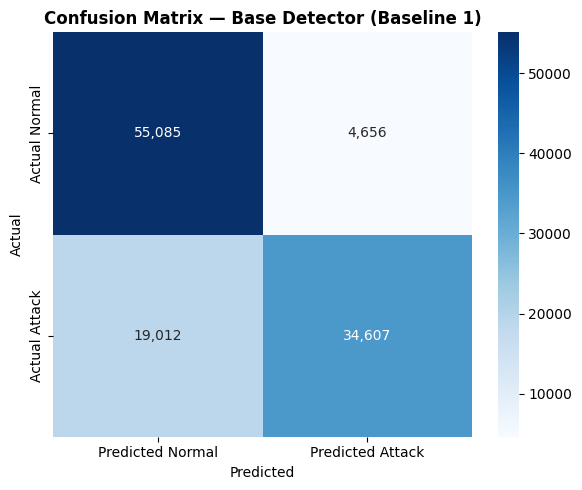

Confusion matrix saved.


In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal',   'Actual Attack'])
ax.set_title('Confusion Matrix — Base Detector (Baseline 1)', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

## 3.5 — ROC curve

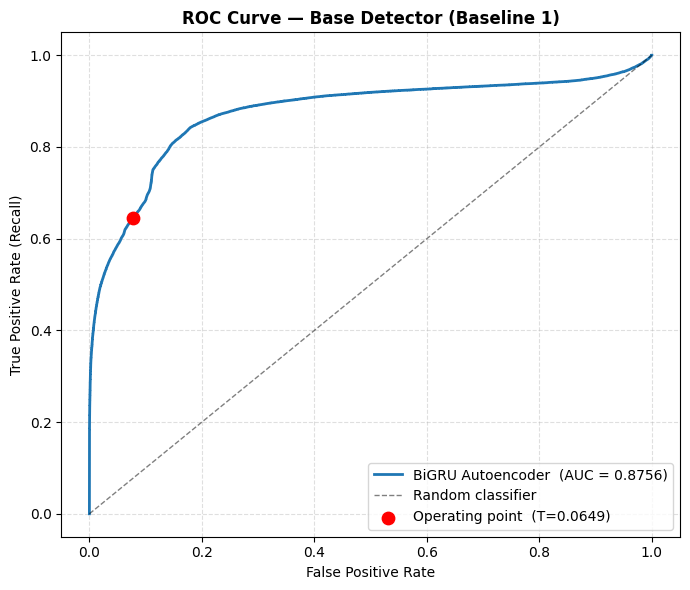

ROC curve saved.


In [12]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, test_errors)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_curve, tpr_curve, color='#1f77b4', linewidth=2,
        label=f'BiGRU Autoencoder  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.scatter([fpr], [recall], color='red', zorder=5, s=80,
           label=f'Operating point  (T={THRESHOLD_T:.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Base Detector (Baseline 1)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curve saved.')

## 3.6 — Per-attack-class breakdown

Detection rate per attack type reveals which threats the base detector handles
well and which it struggles with. This is important context for the LoRA
adaptation story — if certain attack types have low recall, adaptation should improve them.

In [14]:
classes      = np.unique(y_test_class)
class_results = []

for cls in classes:
    mask     = y_test_class == cls
    y_true_c = y_test[mask]
    y_pred_c = y_pred[mask]
    errors_c = test_errors[mask]
    n        = mask.sum()

    if cls == 'Benign':
        # For benign: correct = predicted normal (true negatives)
        correct_rate = (y_pred_c == 0).mean()
        label        = 'Correct (not flagged)'
    else:
        # For attacks: correct = predicted anomaly (true positives)
        correct_rate = (y_pred_c == 1).mean()
        label        = 'Detection rate'

    mean_err = errors_c.mean()
    class_results.append({
        'Class'         : cls,
        'Sequences'     : n,
        'Mean Error'    : round(mean_err, 5),
        label           : f'{correct_rate:.1%}',
        'vs Threshold'  : f'{mean_err/THRESHOLD_T:.2f}x'
    })

results_df = pd.DataFrame(class_results)
print('Per-class detection results:')
print(results_df.to_string(index=False))

Per-class detection results:
     Class  Sequences  Mean Error Correct (not flagged) vs Threshold Detection rate
    Benign      59741     0.04351                 92.2%        0.67x            NaN
BruteForce       3619     0.02022                   NaN        0.31x           0.0%
      DDoS      10000     0.11159                   NaN        1.72x          98.9%
       DoS      10000     0.09078                   NaN        1.40x          94.0%
     Mirai      10000     0.08469                   NaN        1.31x          89.3%
     Recon      10000     0.06241                   NaN        0.96x          21.6%
  Spoofing      10000     0.06273                   NaN        0.97x          42.3%


## 3.7 — Per-feature reconstruction error: normal vs attack

Shows which features contribute most to the reconstruction error gap between
normal and attack traffic. Features with the highest attack/normal error ratio
are the most diagnostically useful — these will appear most frequently in
the surrogate decision tree rules in Stage 4.

Per-feature reconstruction error (sorted by attack/normal ratio):
                Feature  Normal Error  Attack Error  Attack/Normal
           RST_FLAG_CNT      0.044431      0.373950       8.416405
         TCP_WIN_MAX_IN      0.019576      0.079222       4.046841
        TCP_WIN_MAX_OUT      0.013691      0.049213       3.594584
            ACTIVE_MEAN      0.033146      0.089889       2.711941
           PKT_LEN_MEAN      0.023283      0.060609       2.603185
           SYN_FLAG_CNT      0.057622      0.121181       2.103028
           FIN_FLAG_CNT      0.058470      0.115969       1.983405
       LONGEST_FLOW_PKT      0.022070      0.034336       1.555751
SRC_TO_DST_SECOND_BYTES      0.013347      0.018187       1.362640
          DOWN_UP_RATIO      0.058437      0.075389       1.290105
     SRC_TO_DST_IAT_MIN      0.024588      0.030720       1.249399
          FLOW_IAT_MEAN      0.028142      0.032867       1.167902
               IN_BYTES      0.035442      0.040067       1.130

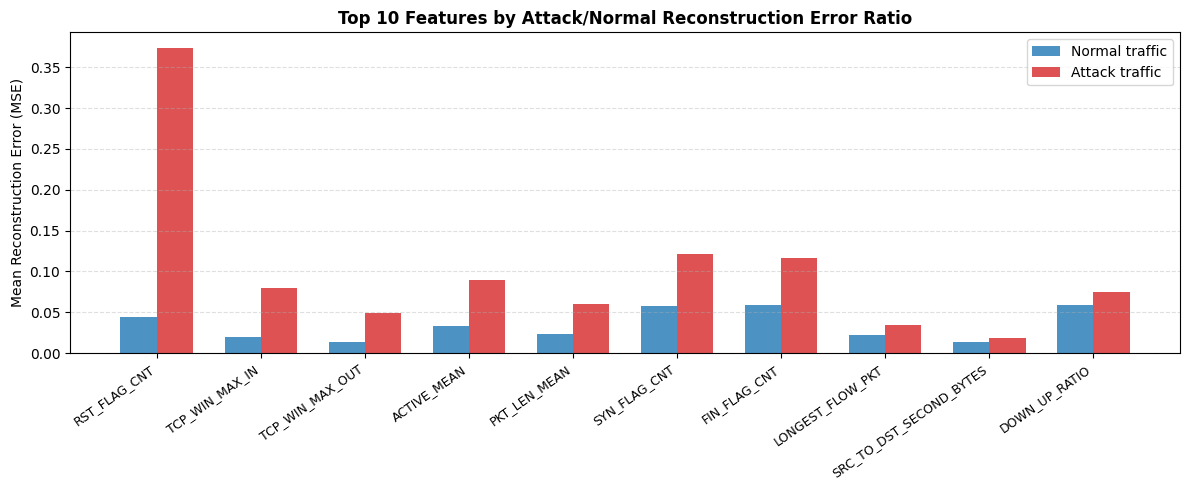

Feature error comparison saved.


In [15]:
normal_mask = y_test == 0
attack_mask = y_test == 1

normal_feat_errors = per_feature_errors[normal_mask].mean(axis=0)  # (19,)
attack_feat_errors = per_feature_errors[attack_mask].mean(axis=0)  # (19,)
ratio              = attack_feat_errors / (normal_feat_errors + 1e-9)

feat_df = pd.DataFrame({
    'Feature'          : FEATURES,
    'Normal Error'     : normal_feat_errors,
    'Attack Error'     : attack_feat_errors,
    'Attack/Normal'    : ratio
}).sort_values('Attack/Normal', ascending=False).reset_index(drop=True)

print('Per-feature reconstruction error (sorted by attack/normal ratio):')
print(feat_df.to_string(index=False))

# ── Bar chart: top features by error ratio ────────────────────────────────────
top_n  = 10
top_df = feat_df.head(top_n)

x      = np.arange(top_n)
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, top_df['Normal Error'], width,
       label='Normal traffic', color='#1f77b4', alpha=0.8)
ax.bar(x + width/2, top_df['Attack Error'], width,
       label='Attack traffic', color='#d62728', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_df['Feature'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean Reconstruction Error (MSE)')
ax.set_title('Top 10 Features by Attack/Normal Reconstruction Error Ratio',
             fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'feature_error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature error comparison saved.')

## 3.8 — Reconstruction error distribution: normal vs attack

Visualises the separation between normal and attack reconstruction errors.
A clear gap with minimal overlap means the threshold is well-positioned.
Overlap in this plot corresponds directly to FP and FN errors.

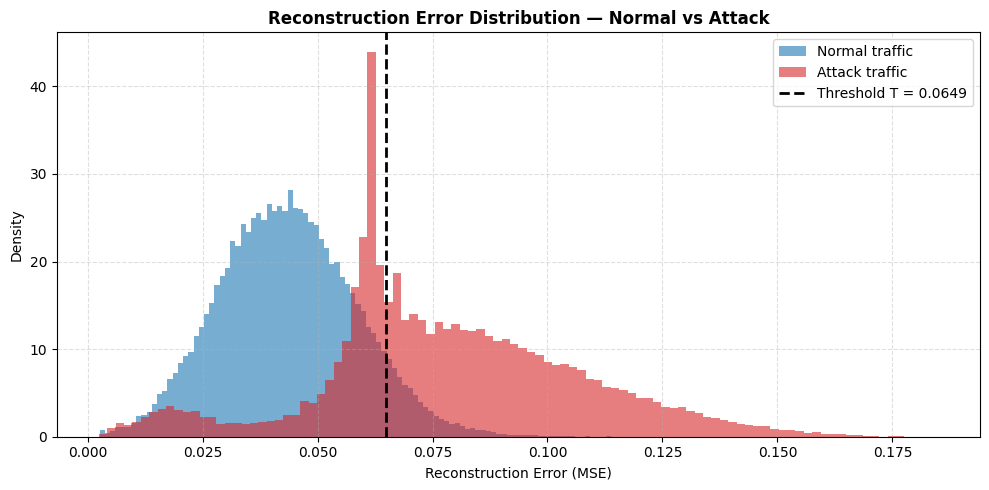

Error distribution plot saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(test_errors[normal_mask], bins=100, alpha=0.6,
        color='#1f77b4', label='Normal traffic', density=True)
ax.hist(test_errors[attack_mask], bins=100, alpha=0.6,
        color='#d62728', label='Attack traffic', density=True)
ax.axvline(THRESHOLD_T, color='black', linewidth=2, linestyle='--',
           label=f'Threshold T = {THRESHOLD_T:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Reconstruction Error Distribution — Normal vs Attack', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'error_distribution_normal_vs_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print('Error distribution plot saved.')

## 3.9 — Save Stage 3 outputs

In [17]:
np.save(SAVE_DIR + 'test_errors.npy',       test_errors)
np.save(SAVE_DIR + 'per_feature_errors.npy', per_feature_errors)
np.save(SAVE_DIR + 'y_pred_baseline.npy',    y_pred)

with open(SAVE_DIR + 'stage3_assets.pkl', 'wb') as f:
    pickle.dump({
        'baseline1_metrics' : baseline1_metrics,
        'feat_df'           : feat_df,
    }, f)

print('=' * 55)
print('STAGE 3 COMPLETE')
print('=' * 55)
print(f'  ROC-AUC   : {baseline1_metrics["roc_auc"]:.4f}  (primary metric)')
print(f'  F1        : {baseline1_metrics["f1"]:.4f}')
print(f'  Recall    : {baseline1_metrics["recall"]:.4f}')
print(f'  FPR       : {baseline1_metrics["fpr"]:.4f}')
print()
print('Saved to Google Drive:')
print('  test_errors.npy')
print('  per_feature_errors.npy')
print('  y_pred_baseline.npy')
print('  stage3_assets.pkl')
print()
print('Ready for Stage 4 — Surrogate Decision Tree + Pre-Adaptation Fidelity')
print('NOTE: Model will be FROZEN at the start of Stage 4.')
print('=' * 55)

STAGE 3 COMPLETE
  ROC-AUC   : 0.8756  (primary metric)
  F1        : 0.7452
  Recall    : 0.6454
  FPR       : 0.0779

Saved to Google Drive:
  test_errors.npy
  per_feature_errors.npy
  y_pred_baseline.npy
  stage3_assets.pkl

Ready for Stage 4 — Surrogate Decision Tree + Pre-Adaptation Fidelity
NOTE: Model will be FROZEN at the start of Stage 4.
